# Exploratory Data Analysis: Job Search Anxiety Detection Survey 
## 1. Import Required Libraries

In [1]:
%pip install pandas numpy matplotlib seaborn scipy wordcloud

  Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.1.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, chi2_contingency
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
from wordcloud import WordCloud, STOPWORDS

## 2. Data Preparation

In [3]:
df = pd.read_csv('../data/form_responses.csv')
survey_dict = pd.read_csv('../data/survey_qns_data_dict.csv')
df = df[(df['ac1'] == 2) & (df['ac2'] == 0)].drop(columns=['ac1', 'ac2'])
code_to_question = dict(zip(survey_dict["Code"], survey_dict["Question"]))

print(f"Dataset shape: {df.shape}")
print(f"Number of respondents: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print("Dataset Sample:")
df.head()

Dataset shape: (54, 32)
Number of respondents: 54
Number of features: 32
Dataset Sample:


,timestamp,consent,demo_gender,demo_area_of_study,demo_honours_class,demo_job_search_status,demo_num_prior_interns,demo_financial_urgency,feas_pa1,feas_pa2,...,feas_sr2,feas_sr3,feas_sr4,bhv_apps_4_wks,bhv_itvs_4_wks,bhv_job_update_check_daily,bhv_app_duration,bhv_app_status_check_daily,bhv_app_avoidance_weekly,bhv_job_search_exp
0,2/24/2026 8:47:57,I agree,Male,Computing and Data,Honours (Highest Distinction),Actively applying,1-2,5,5,2,...,2,1,2,31+,2 - 3,1 - 2,<10 min,1 - 2,1 - 2,Not knowing what the companies want. Sometimes...
1,2/24/2026 11:51:05,I agree,Female,Computing and Data,Honours (Distinction),Actively applying,1-2,3,5,4,...,2,4,2,6 - 15,1,1 - 2,10 - 30 min,0,3 - 5,I dl being on LinkedIn sometimes it’s a luck g...
2,2/24/2026 11:55:42,I agree,Female,Design & Engineering,Honours (Highest Distinction),Actively applying,1-2,2,4,2,...,5,4,2,16 - 30,0,3 - 5,10 - 30 min,1 - 2,1 - 2,1. Not making good progress - not trying hard ...
3,2/24/2026 12:07:31,I agree,Male,Design & Engineering,Honours (Distinction),Actively applying,1-2,5,2,2,...,4,4,4,0,1,3 - 5,10 - 30 min,1 - 2,0,1. Social circle: I feel worried when I hear o...
4,2/24/2026 12:08:09,I agree,Female,Computing and Data,Honours (Distinction),Secured but still actively applying,3 and above,2,4,4,...,3,2,4,16 - 30,1,1 - 2,10 - 30 min,1 - 2,3 - 5,Seeing people get to big companies feels a lit...


In [4]:
intern_order = ["0", "1-2", "3 and above"]
df["demo_num_prior_interns"] = pd.Categorical(df["demo_num_prior_interns"], categories=intern_order, ordered=True)

job_order = [
    "Not started",
    "Planning to apply soon",
    "Actively applying",
    "Secured but still actively appleying",
    "Already secured job"
]
df["demo_job_search_status"] = pd.Categorical(df["demo_job_search_status"], categories=job_order, ordered=True)

honours_order = [
    "Honours (Highest Distinction)",
    "Honours (Distinction)",
    "Honours (Merit)",
    "Honours",
    "Pass"
]
df["demo_honours_class"] = pd.Categorical(df["demo_honours_class"], categories=honours_order, ordered=True)

apps_order = ["0", "1 - 5", "6 - 15", "16 - 30", "31+"]
df["bhv_apps_4_wks"] = pd.Categorical(df["bhv_apps_4_wks"], categories=apps_order, ordered=True)

itvs_order = ["0", "1", "2 - 3", "4+"]
df["bhv_itvs_4_wks"] = pd.Categorical(df["bhv_itvs_4_wks"], categories=itvs_order, ordered=True)

freq_order = ["0", "1 - 2", "3-5", "6+", "Not Applicable"]

df["bhv_job_update_check_daily"] = pd.Categorical(df["bhv_job_update_check_daily"], categories=freq_order, ordered=True)
df["bhv_app_status_check_daily"] = pd.Categorical(df["bhv_app_status_check_daily"], categories=freq_order, ordered=True)
df["bhv_app_avoidance_weekly"] = pd.Categorical(df["bhv_app_avoidance_weekly"], categories=freq_order, ordered=True)

duration_order = ["<10 min", "10 - 30 min", "30 - 60 min", "1 - 2 h", "> 2 h", "Not Applicable"]
df["bhv_app_duration"] = pd.Categorical(df["bhv_app_duration"], categories=duration_order, ordered=True)

In [5]:
feas_pa = [col for col in df.columns if col.startswith('feas_pa')]
feas_ka = [col for col in df.columns if col.startswith('feas_ka')]
feas_cr = [col for col in df.columns if col.startswith('feas_cr')]
feas_sr = [col for col in df.columns if col.startswith('feas_sr')]

df['anxiety_pa'] = df[feas_pa].mean(axis=1)
df['anxiety_ka'] = df[feas_ka].mean(axis=1)
df['anxiety_cr'] = df[feas_cr].mean(axis=1)
df['anxiety_sr'] = df[feas_sr].mean(axis=1)

all_feas = feas_pa + feas_ka + feas_cr + feas_sr
df['anxiety_overall'] = df[all_feas].mean(axis=1)

## 3. Demographic Analysis

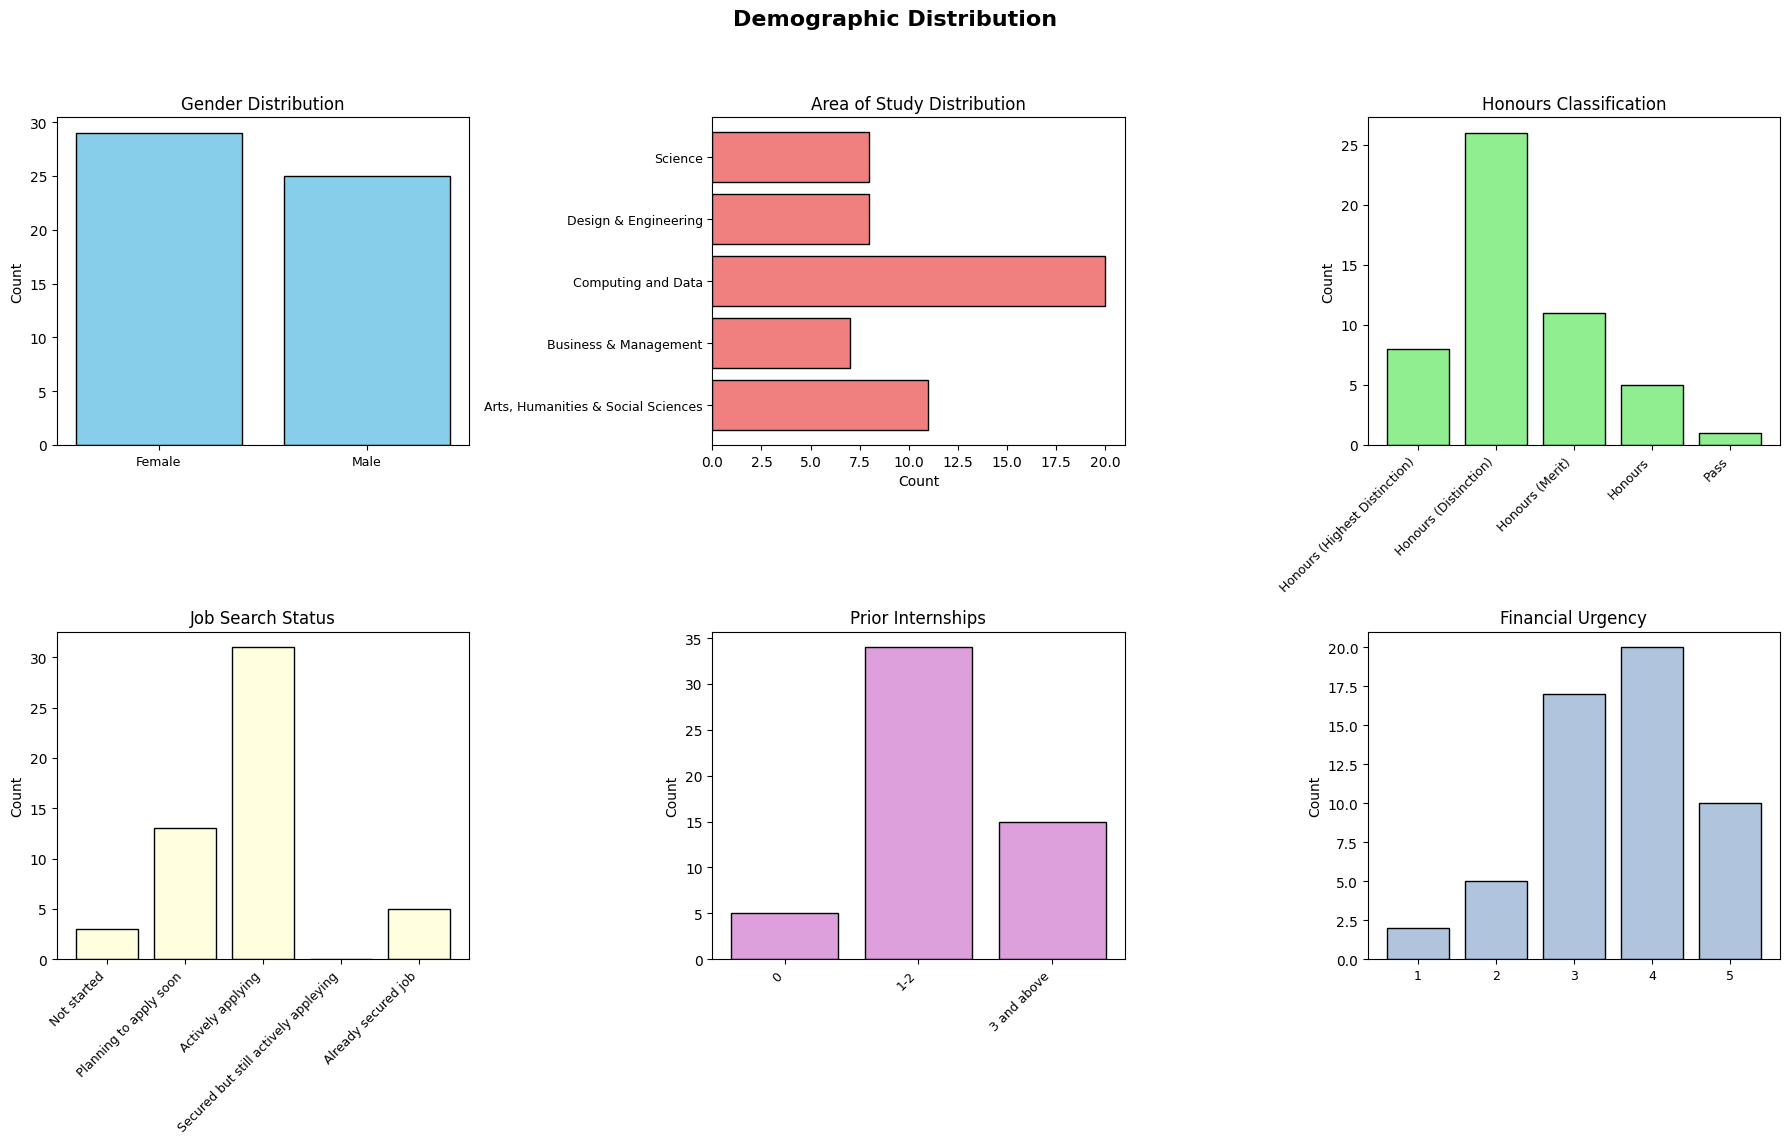

In [6]:
def plot_bar(group_col, ax, title, color, horizontal=False):
    counts = df[group_col].value_counts().sort_index()

    if horizontal:
        ax.barh(range(len(counts)), counts.values, color=color, edgecolor='black')
        ax.set_yticks(range(len(counts)))
        ax.set_yticklabels(counts.index, fontsize=9)
        ax.set_xlabel('Count')
    else:
        ax.bar(range(len(counts)), counts.values, color=color, edgecolor='black')
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(counts.index, fontsize=9)
        ax.set_ylabel('Count')
        
        if any(len(str(label)) > 10 for label in counts.index):
            plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    ax.set_title(title, fontsize=12)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Demographic Distribution', fontsize=16, fontweight='bold')

plot_bar('demo_gender', axes[0, 0], 'Gender Distribution', 'skyblue')
plot_bar('demo_area_of_study', axes[0, 1], 'Area of Study Distribution', 'lightcoral', horizontal=True)
plot_bar('demo_honours_class', axes[0, 2], 'Honours Classification', 'lightgreen')
plot_bar('demo_job_search_status', axes[1, 0], 'Job Search Status', 'lightyellow')
plot_bar('demo_num_prior_interns', axes[1, 1], 'Prior Internships', 'plum')
plot_bar('demo_financial_urgency', axes[1, 2], 'Financial Urgency', 'lightsteelblue')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


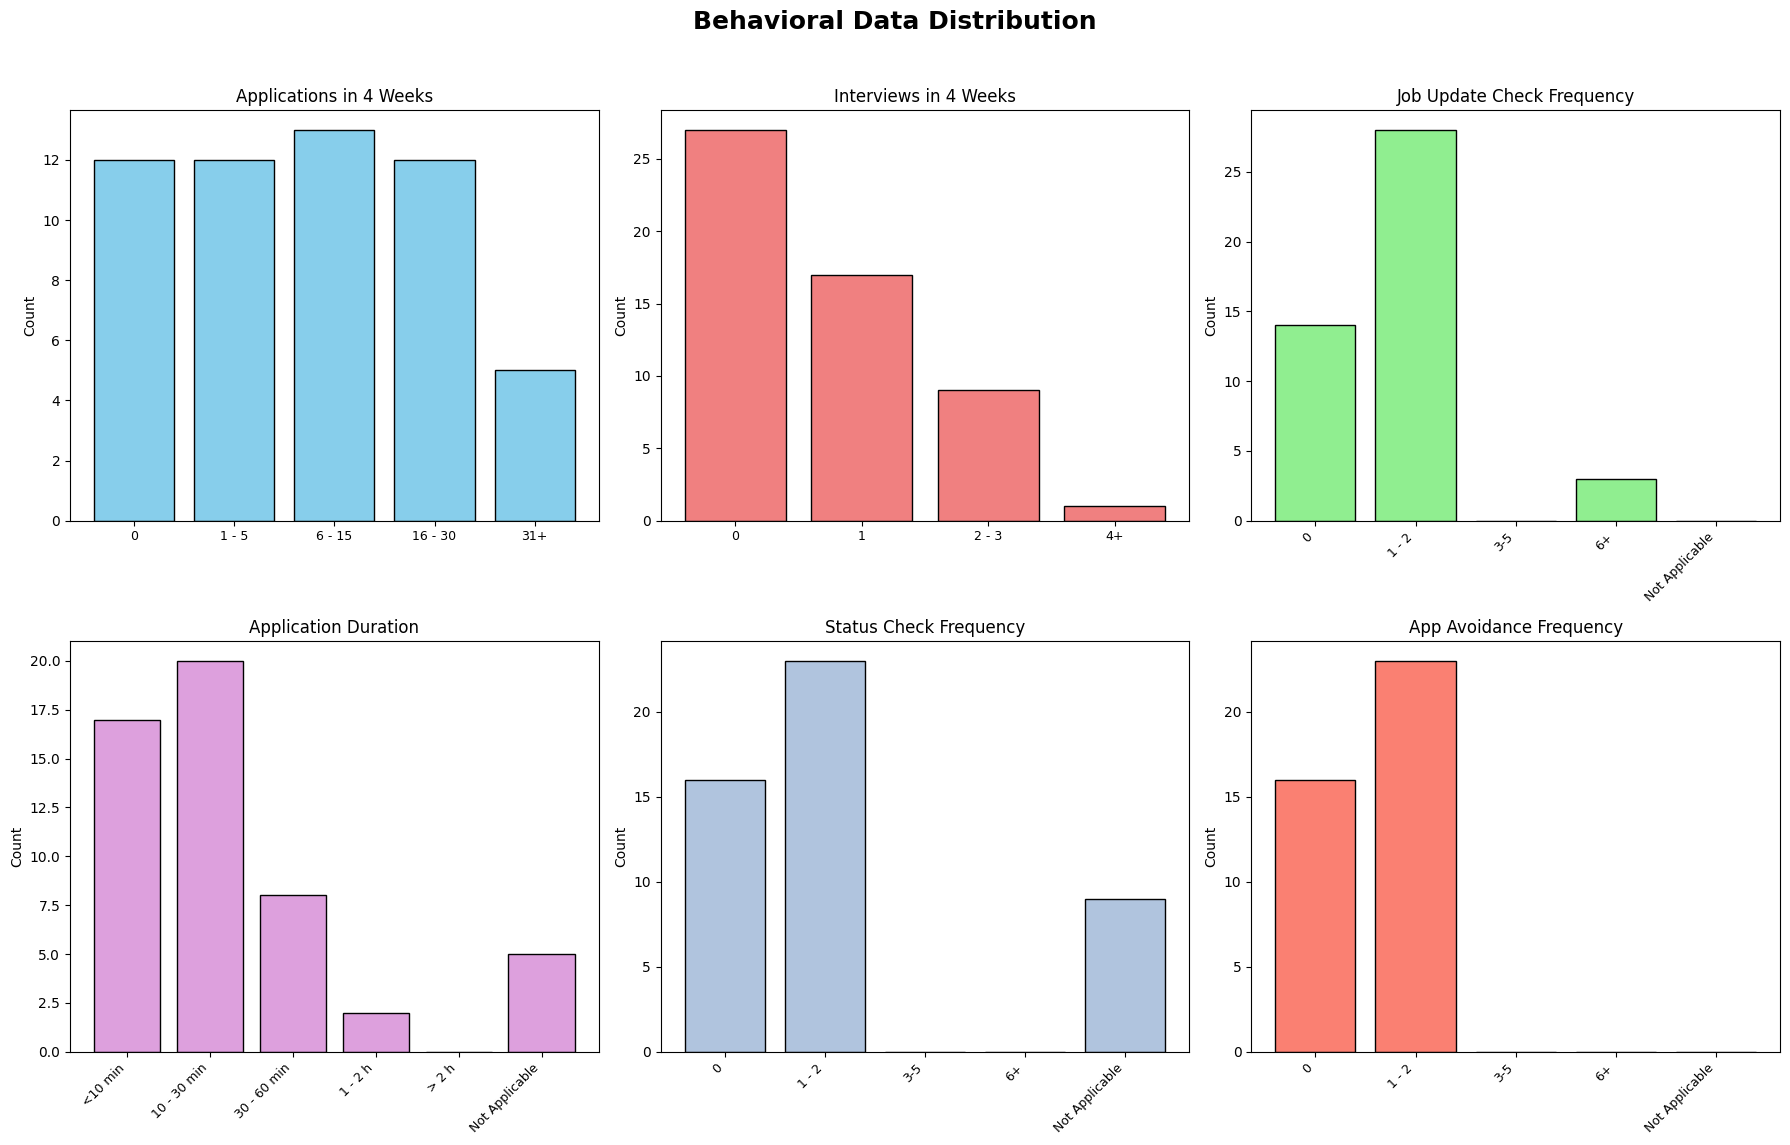

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Behavioral Data Distribution', fontsize=18, fontweight='bold')

plot_bar('bhv_apps_4_wks', axes[0, 0], 'Applications in 4 Weeks', 'skyblue')
plot_bar('bhv_itvs_4_wks', axes[0, 1], 'Interviews in 4 Weeks', 'lightcoral')
plot_bar('bhv_job_update_check_daily', axes[0, 2], 'Job Update Check Frequency', 'lightgreen')
plot_bar('bhv_app_duration', axes[1, 0], 'Application Duration', 'plum')
plot_bar('bhv_app_status_check_daily', axes[1, 1], 'Status Check Frequency', 'lightsteelblue')
plot_bar('bhv_app_avoidance_weekly', axes[1, 2], 'App Avoidance Frequency', 'salmon')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

## 4. Anxiety Distribution
The Future Employment Anxiety Scale (FEAS) is divided into 4 subscales:
- **Personal Ability (PA)**: Questions about general professional competence (PA1-PA5)
- **Knowledge Application (KA)**: Questions about applying academic knowledge (KA1-KA4)
- **Career Replaceability (CR)**: Questions about job replacement concerns (CR1-CR4)
- **Social Relations (SR)**: Questions about workplace relationships (SR1-SR4)
### 4.1. Overall Distribution

       anxiety_pa  anxiety_ka  anxiety_cr  anxiety_sr  anxiety_overall
count      54.000      54.000      54.000      54.000           54.000
mean        3.111       3.542       3.352       2.866            3.211
std         0.862       0.976       0.972       0.890            0.670
min         1.200       1.000       1.000       1.250            1.529
25%         2.400       3.000       2.500       2.000            2.647
50%         3.200       3.750       3.500       2.875            3.382
75%         3.800       4.250       4.188       3.500            3.706
max         4.600       5.000       5.000       4.750            4.412


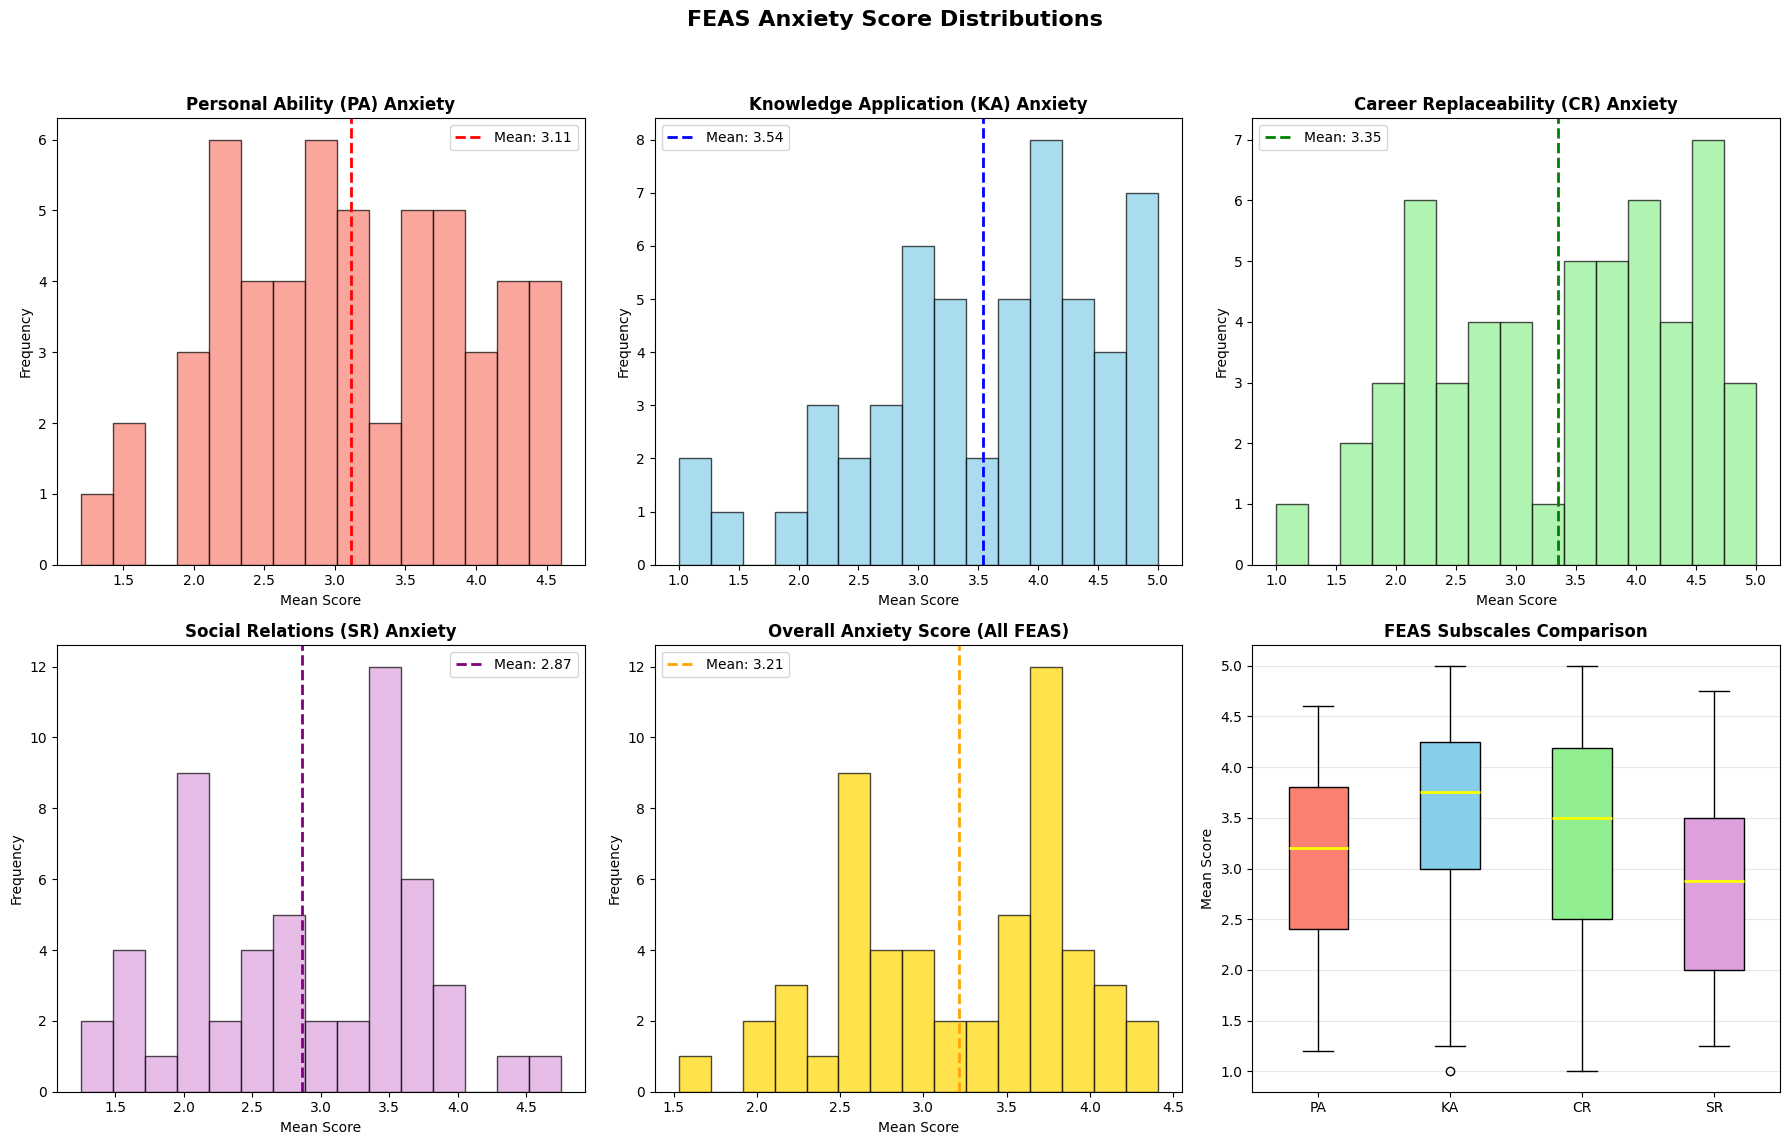

In [8]:
anxiety_cols = ['anxiety_pa', 'anxiety_ka', 'anxiety_cr', 'anxiety_sr', 'anxiety_overall']
print(df[anxiety_cols].describe().round(3))

def plot_anxiety_hist(df, col, ax, title, color, line_color):

    mean_val = df[col].mean()

    ax.hist(df[col], bins=15, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(mean_val, color=line_color, linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.2f}')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Score')
    ax.set_ylabel('Frequency')
    ax.legend()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('FEAS Anxiety Score Distributions', fontsize=16, fontweight='bold')

colors = {'pa': 'salmon', 'ka': 'skyblue', 'cr': 'lightgreen', 'sr': 'plum', 'overall': 'gold'}
line_colors = {'pa': 'red', 'ka': 'blue', 'cr': 'green', 'sr': 'purple', 'overall': 'orange'}

plot_anxiety_hist(df, 'anxiety_pa', axes[0, 0], 'Personal Ability (PA) Anxiety', colors['pa'], line_colors['pa'])
plot_anxiety_hist(df, 'anxiety_ka', axes[0, 1], 'Knowledge Application (KA) Anxiety', colors['ka'], line_colors['ka'])
plot_anxiety_hist(df, 'anxiety_cr', axes[0, 2], 'Career Replaceability (CR) Anxiety', colors['cr'], line_colors['cr'])
plot_anxiety_hist(df, 'anxiety_sr', axes[1, 0], 'Social Relations (SR) Anxiety', colors['sr'], line_colors['sr'])
plot_anxiety_hist(df, 'anxiety_overall', axes[1, 1], 'Overall Anxiety Score (All FEAS)', colors['overall'], line_colors['overall'])

ax_box = axes[1, 2]
anxiety_data = [df['anxiety_pa'], df['anxiety_ka'], df['anxiety_cr'], df['anxiety_sr']]
bp = ax_box.boxplot(anxiety_data, labels=['PA', 'KA', 'CR', 'SR'], patch_artist=True, 
                    medianprops=dict(color='yellow', linewidth=2))

for patch, color in zip(bp['boxes'], [colors['pa'], colors['ka'], colors['cr'], colors['sr']]):
    patch.set_facecolor(color)

ax_box.set_title('FEAS Subscales Comparison', fontsize=12, fontweight='bold')
ax_box.set_ylabel('Mean Score')
ax_box.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The distribution of anxiety scores is bimodal, suggesting the presence of two distinct subpopulations: a lower-anxiety group and a higher-anxiety group. This indicates that job search anxiety is not uniformly experienced but rather concentrated among a subset of individuals. We can also see that the knowledge application aspect has the highest mean and is the most left skewed which suggest that it is the biggest source of anxiety.

Correlation of Individual Questions with Overall Anxiety:
(pa4)I'm worried that my computer knowledge is not as proficient as others.: 0.742
(ka3)I'm worried that the knowledge I acquired in college is not up to date with the latest knowledge (such as programming).: 0.719
(ka1)I'm worried that the knowledge I acquired in college cannot keep up with the development of the times.: 0.717
(cr2)I'm worried that my future job will be replaced by people with higher education background than me.: 0.654
(ka2)I'm worried that the theoretical knowledge I acquired in college cannot solve the problems encountered in my work.: 0.641
(cr1)I'm worried that my future job will be replaced by artificial intelligence (such as translation, painting, etc.).: 0.639
(ka4)I'm worried that the knowledge I acquired in college is too theoretical and cannot adapt to the complex work requirements of today.: 0.597
(cr3)I'm worried that my future job will be replaced by people who require lower salary and benefits th

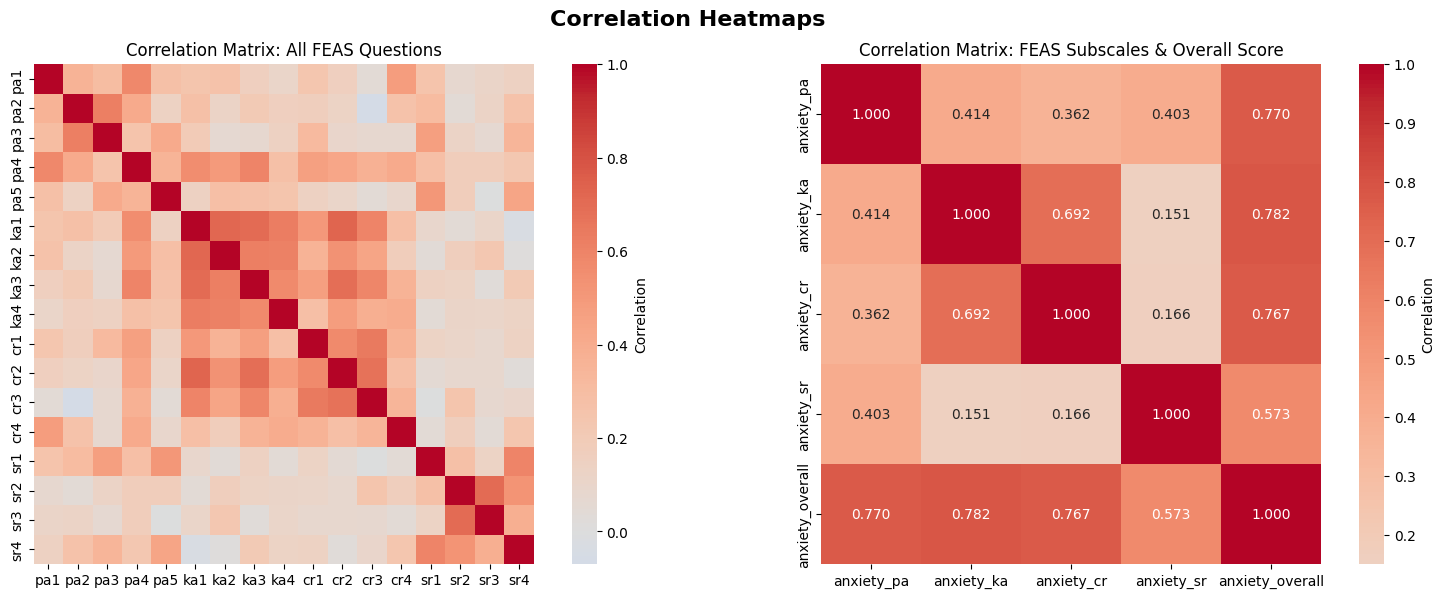

In [9]:
print("Correlation of Individual Questions with Overall Anxiety:")
correlations = df[all_feas].corrwith(df['anxiety_overall']).sort_values(ascending=False)
for question, corr in correlations.items():
    print(f"{'(' + question.replace('feas_', '') + ')'}{code_to_question.get(question, question)}: {corr:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation Heatmaps', fontsize=16, fontweight='bold')

ax = axes[0]
feas_corr = df[all_feas].corr()
sns.heatmap(feas_corr, cmap='coolwarm', center=0, square=True, ax=ax, 
            xticklabels=[q.replace('feas_', '') for q in all_feas],
            yticklabels=[q.replace('feas_', '') for q in all_feas],
            cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix: All FEAS Questions')

ax = axes[1]
subscale_corr = df[anxiety_cols].corr()
sns.heatmap(subscale_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix: FEAS Subscales & Overall Score')

plt.tight_layout()
plt.show()

The data reveals that technical proficiency and the relevance of academic knowledge are the factors most highly correlated with overall job search anxiety. As the global workforce transitions into a rapidly evolving AI era, traditional university curricula may struggle to keep pace, leading students to feel underprepared for modern workplace demands. This misalignment between formal education and industry expectations appears to be a primary driver of the anxiety observed in the study. From the correlation heatmaps, it suggest that social relations is the least relevant to job search anxiety.
### 4.2. Distribution by Demographics 

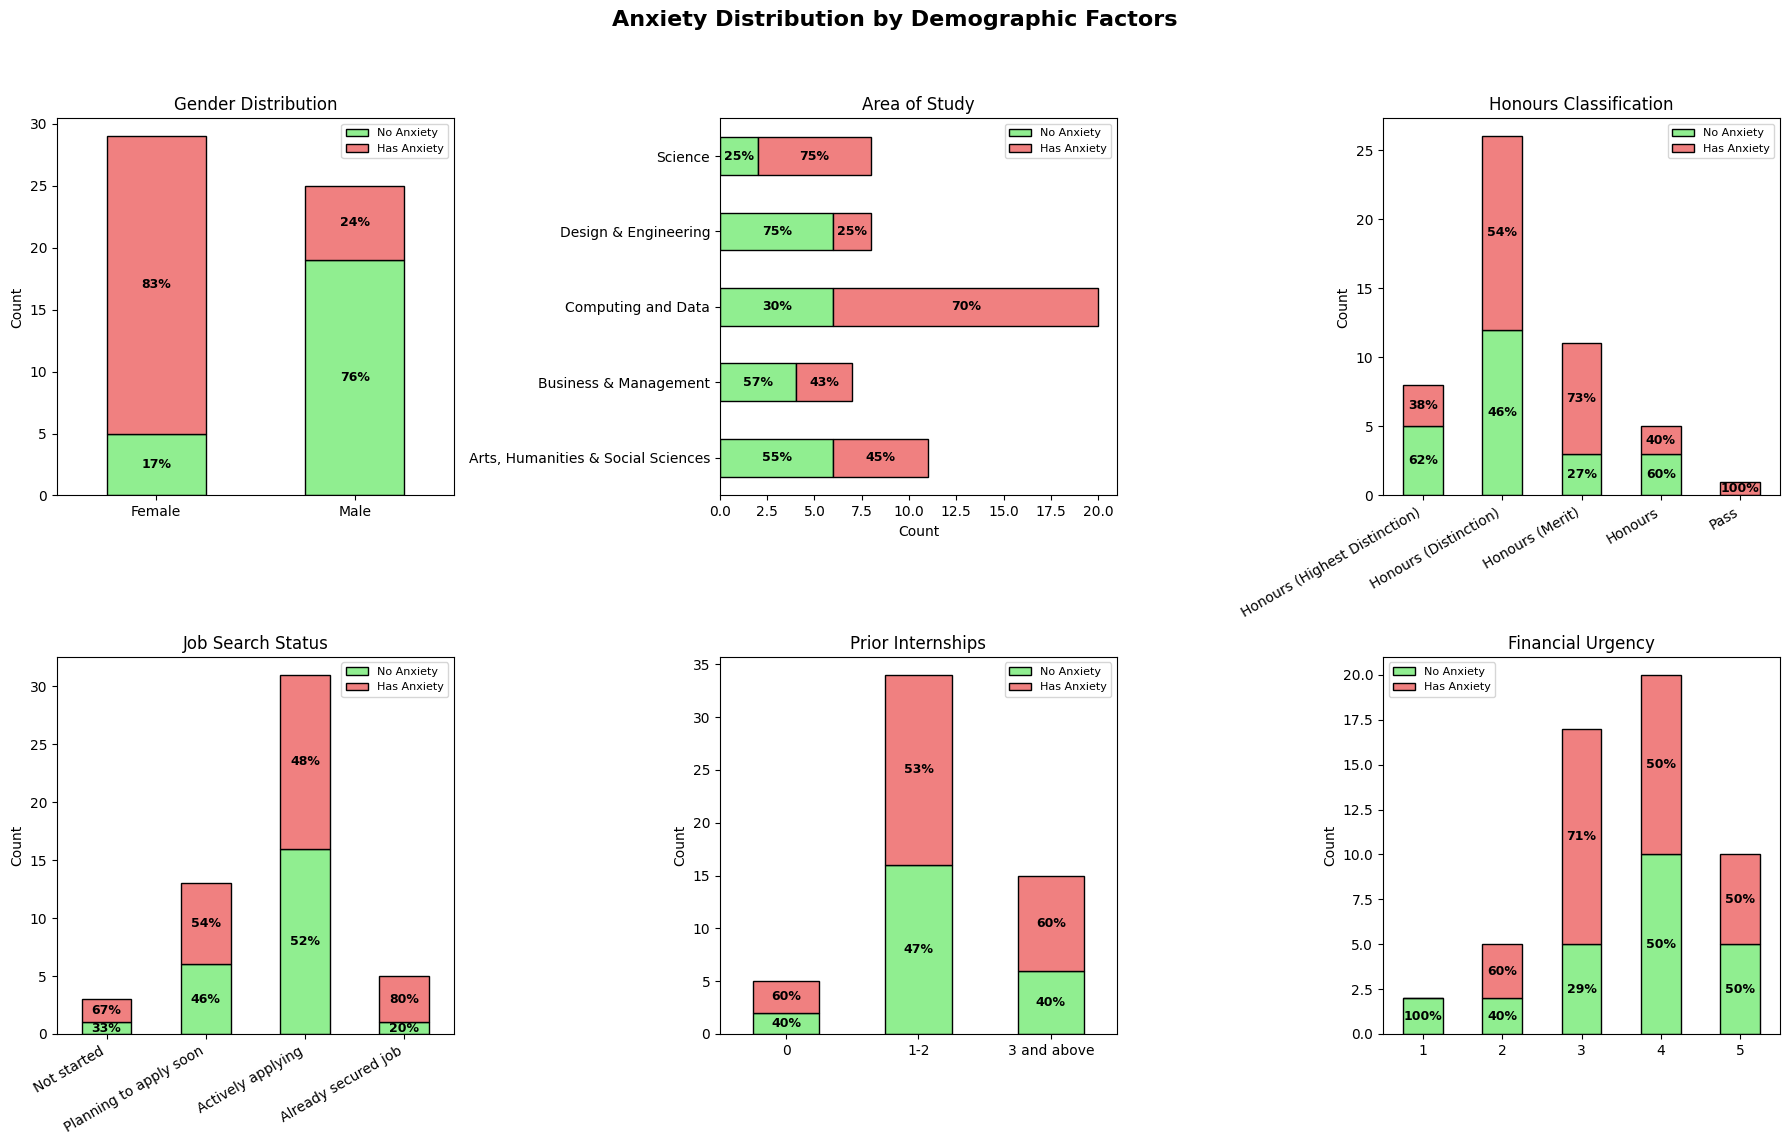

In [10]:
df['has_anxiety'] = (df['anxiety_overall'] > df['anxiety_overall'].mean()).astype(int)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Anxiety Distribution by Demographic Factors', fontsize=16, fontweight='bold')

def plot_styled_stacked(group_col, ax, title, horizontal=False):
    ct = pd.crosstab(df[group_col], df['has_anxiety']).reindex(columns=[0, 1], fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    kind = 'barh' if horizontal else 'bar'
    ct.plot(kind=kind, stacked=True, ax=ax, color=['lightgreen', 'lightcoral'], edgecolor='black')

    for i in range(len(ct)):
        no_val, has_val = ct.iloc[i, 0], ct.iloc[i, 1]
        no_pct, has_pct = ct_pct.iloc[i, 0], ct_pct.iloc[i, 1]
        if no_pct > 5:
            pos = no_val / 2
            ax.text(pos if horizontal else i, i if horizontal else pos, 
                    f"{no_pct:.0f}%", ha='center', va='center', fontsize=9, fontweight='bold')
        if has_pct > 5:
            pos = no_val + (has_val / 2)
            ax.text(pos if horizontal else i, i if horizontal else pos, 
                    f"{has_pct:.0f}%", ha='center', va='center', fontsize=9, fontweight='bold')

    ax.set_title(title)
    ax.set_ylabel('Count' if not horizontal else '')
    ax.set_xlabel('Count' if horizontal else '')

    if not horizontal:
        labels = [l.get_text() for l in ax.get_xticklabels()]
        if any(len(label) > 15 for label in labels):
            plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
        else:
            plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
    
    ax.legend(['No Anxiety', 'Has Anxiety'], fontsize=8)

plot_styled_stacked('demo_gender', axes[0, 0], 'Gender Distribution')
plot_styled_stacked('demo_area_of_study', axes[0, 1], 'Area of Study', horizontal=True)
plot_styled_stacked('demo_honours_class', axes[0, 2], 'Honours Classification')
plot_styled_stacked('demo_job_search_status', axes[1, 0], 'Job Search Status')
plot_styled_stacked('demo_num_prior_interns', axes[1, 1], 'Prior Internships')
plot_styled_stacked('demo_financial_urgency', axes[1, 2], 'Financial Urgency')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [11]:
print("Anxiety by Gender:")
print(df.groupby('demo_gender')[anxiety_cols].mean().round(3))

print("\nAnxiety by Area of Study:")
print(df.groupby('demo_area_of_study')[anxiety_cols].mean().round(3))

Anxiety by Gender:
             anxiety_pa  anxiety_ka  anxiety_cr  anxiety_sr  anxiety_overall
demo_gender                                                                 
Female            3.538       3.784       3.569       3.207            3.525
Male              2.616       3.260       3.100       2.470            2.847

Anxiety by Area of Study:
                                    anxiety_pa  anxiety_ka  anxiety_cr  \
demo_area_of_study                                                       
Arts, Humanities & Social Sciences       2.655       3.205       3.114   
Business & Management                    3.143       3.107       2.964   
Computing and Data                       3.430       3.875       3.750   
Design & Engineering                     2.525       3.469       2.906   
Science                                  3.500       3.625       3.469   

                                    anxiety_sr  anxiety_overall  
demo_area_of_study                                           

Looking into gender and area of study which shows the most variance in job search anxiety, females and science majors have higher anxiety in all aspects than males and other area of study. Computing and data students are especially anxious in knowledge application and career replaceability.
The data shows a significant demographic divide with females and Computing, Data and Science students having substantially higher anxiety than their peers. This is particularly evident in the 'Career Replaceability' subscale, where Computing, Data and Science students’ scores suggest an acute awareness of shifting industry demands. The consistent peak in 'Knowledge Application' anxiety across these groups indicates a widespread perception that traditional academic training may not sufficiently prepare graduates for modern workplace complexities.

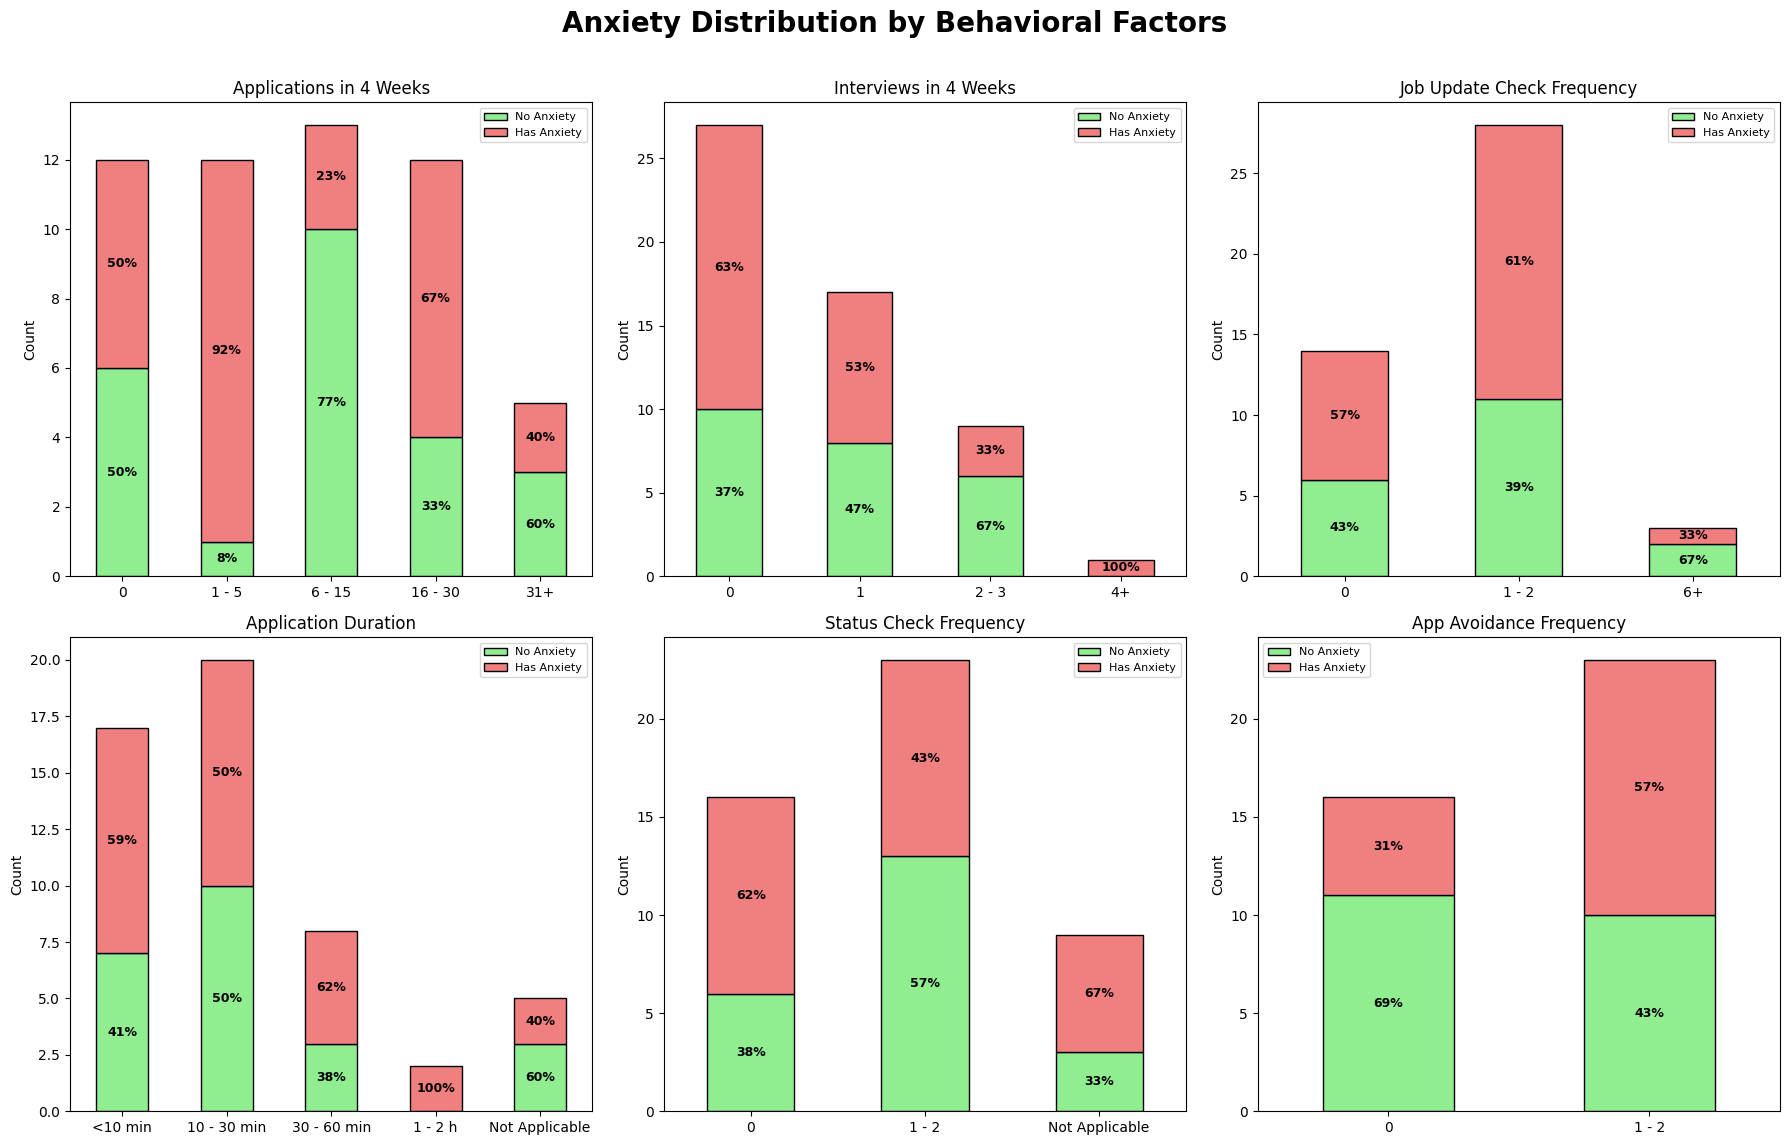

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Anxiety Distribution by Behavioral Factors', fontsize=20, fontweight='bold')

plot_styled_stacked('bhv_apps_4_wks', axes[0, 0], 'Applications in 4 Weeks')
plot_styled_stacked('bhv_itvs_4_wks', axes[0, 1], 'Interviews in 4 Weeks')
plot_styled_stacked('bhv_job_update_check_daily', axes[0, 2], 'Job Update Check Frequency')
plot_styled_stacked('bhv_app_duration', axes[1, 0], 'Application Duration')
plot_styled_stacked('bhv_app_status_check_daily', axes[1, 1], 'Status Check Frequency')
plot_styled_stacked('bhv_app_avoidance_weekly', axes[1, 2], 'App Avoidance Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [13]:
print("Anxiety by Application Frequency:")
print(df.groupby('bhv_apps_4_wks')[anxiety_cols].mean().round(3))

print("\nAnxiety by Interview Frequency:")
print(df.groupby('bhv_itvs_4_wks')[anxiety_cols].mean().round(3))

Anxiety by Application Frequency:
                anxiety_pa  anxiety_ka  anxiety_cr  anxiety_sr  \
bhv_apps_4_wks                                                   
0                    3.367       3.583       3.229       2.812   
1 - 5                3.400       3.854       3.750       3.542   
6 - 15               2.662       3.058       2.750       2.423   
16 - 30              3.183       3.896       3.542       3.021   
31+                  2.800       3.100       3.800       2.150   

                anxiety_overall  
bhv_apps_4_wks                   
0                         3.255  
1 - 5                     3.623  
6 - 15                    2.719  
16 - 30                   3.397  
31+                       2.953  

Anxiety by Interview Frequency:
                anxiety_pa  anxiety_ka  anxiety_cr  anxiety_sr  \
bhv_itvs_4_wks                                                   
0                    3.267       3.694       3.481       2.907   
1                    3.082       3

The data reveals a clear U-shaped relationship between job-seeking effort and anxiety, where moderate activity acts as a protective "sweet spot." For Interview Frequency, anxiety scores drop significantly as students move from 0 to 3 interviews, but spike to their highest point once the volume reaches 4 or more, suggesting that high-stakes interview cycles eventually become overwhelming. A similar trend appears in Application Volume, where anxiety peaks at the 1–5 application level, drops for moderate activity (6–15 apps), and spikes again as volume increases to 16–30 apps. This suggests that while moderate activity provides the most stable mental state, the subsequent spike in the 16–30 range indicates a period of peak burnout that only drops off at the 31+ level as the seeker enters a state of emotional numbness or automation.

## 5. Vocabulary by Anxiety
Note: The mean of the overall anxiety score is used as the threshold for with anxiety

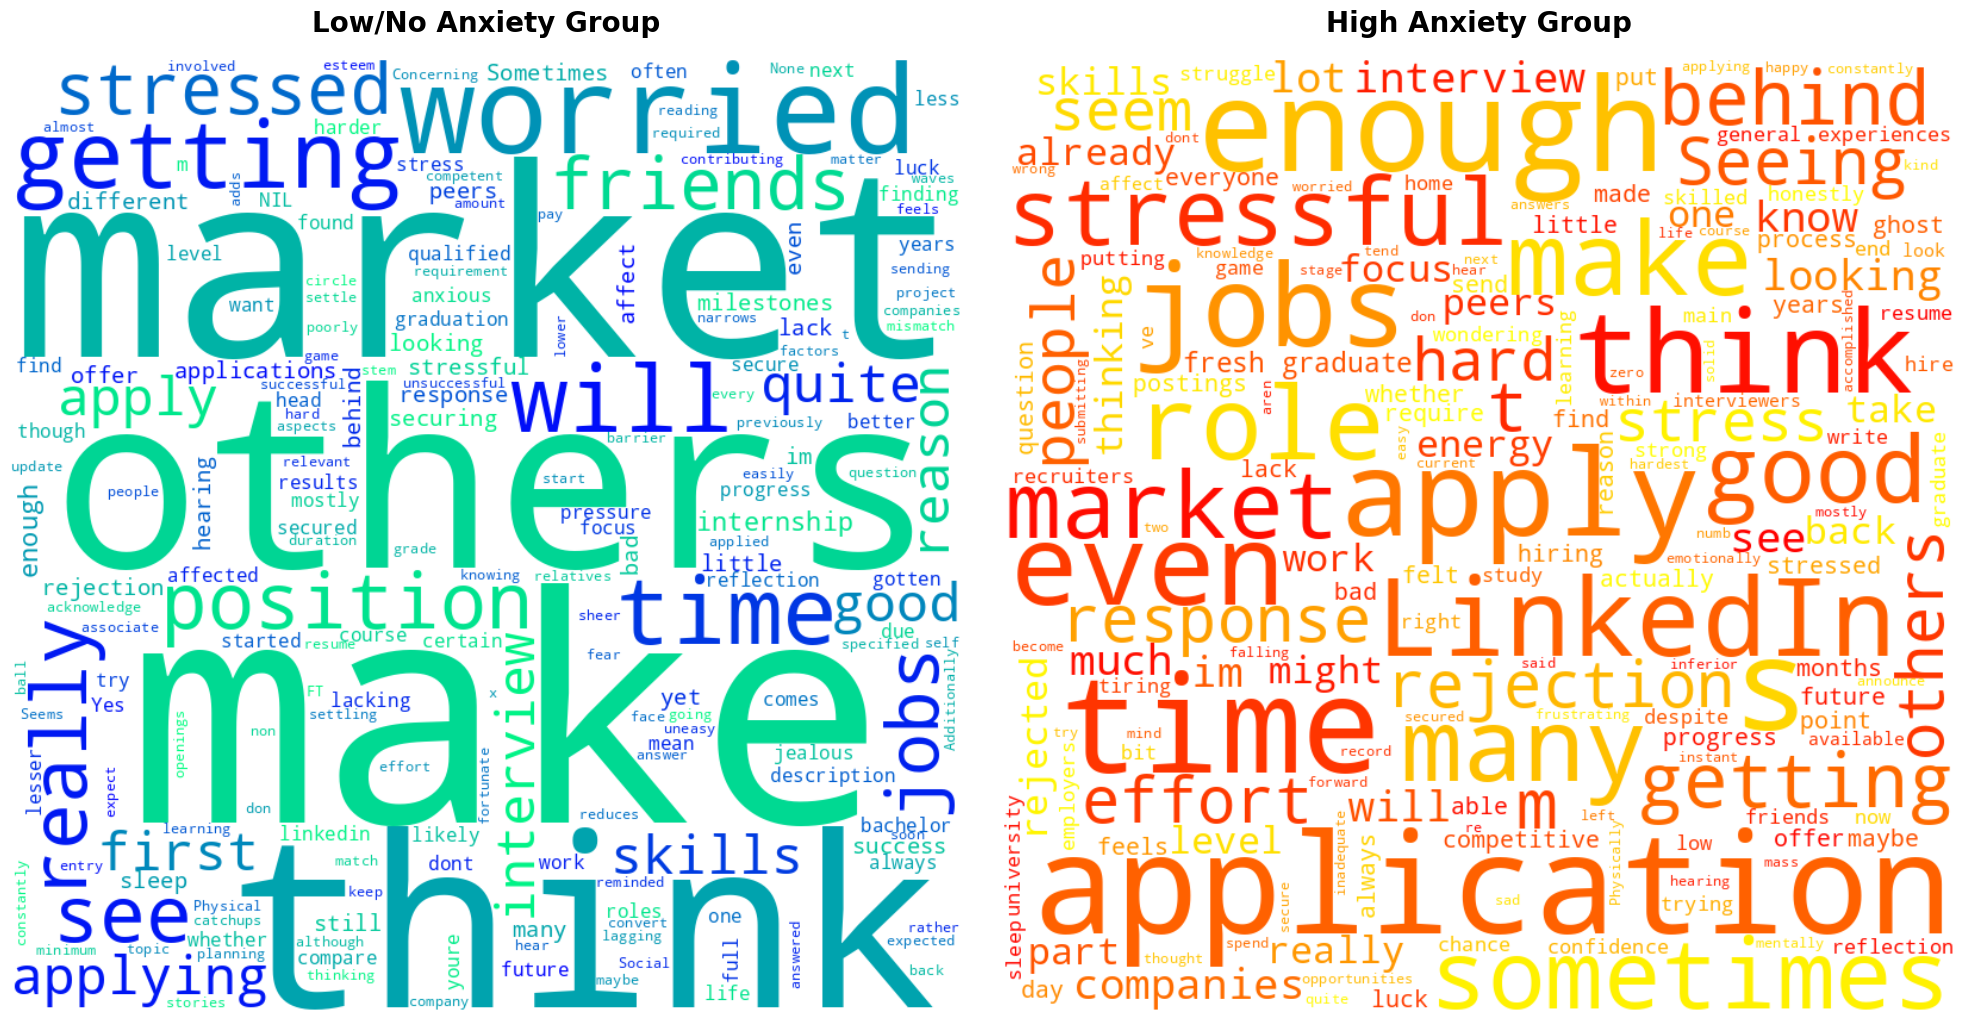

In [14]:
text_col = 'bhv_job_search_exp'
group_col = 'has_anxiety'

custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['job', 'search', 'searching', 'experience', 'week', 'past', 'weeks', 'feel', 'feeling'])

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for i, status in enumerate([0, 1]):
    text_data = df[df[group_col] == status][text_col].dropna().astype(str)
    combined_text = " ".join(text_data)
    
    # Title and Color Logic
    title = "Low/No Anxiety Group" if status == 0 else "High Anxiety Group"
    color_map = 'winter' if status == 0 else 'autumn' # Blue/Green for calm, Red/Orange for stress
    
    if len(combined_text) > 10:
        wc = WordCloud(
            width=800, height=800,
            background_color='white',
            stopwords=custom_stopwords,
            colormap=color_map,
            min_font_size=10
        ).generate(combined_text)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(title, fontsize=20, fontweight='bold', pad=20)
        axes[i].axis("off")
    else:
        axes[i].text(0.5, 0.5, 'Not enough data', ha='center', va='center')
        axes[i].axis("off")

plt.tight_layout()
plt.show()


The qualitative word cloud analysis reveals a distinct shift in perspective between groups. While the low-anxiety group focuses on social comparison (e.g., 'others', 'friends'), the high-anxiety group is dominated by process-driven exhaustion centered around 'LinkedIn', 'applications', and 'rejection'. This suggests that for high-anxiety individuals, the platform-mediated nature of modern job searching—and the constant visibility of 'rejection'—is a primary emotional trigger